<a href="https://colab.research.google.com/github/masroor202233/masroor202233.github.io/blob/master/BTC_Strategy_Research.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


Table: Trend-following and Mean Reversion Performance
    Lookback             Strategy  Ann_Return  Volatility     MDD  Ret/Vol
0         10        Trend: At MAX      0.6551      0.3851 -0.4265   1.7011
1         10  Mean Rev: Below MAX      0.0106      0.6345 -2.5232   0.0168
2         10     Mean Rev: At MIN     -0.0123      0.3311 -0.9637  -0.0371
3         10      Trend: Over MIN      0.6780      0.6642 -2.7769   1.0208
4         20        Trend: At MAX      0.5962      0.3680 -0.4824   1.6202
5         20  Mean Rev: Below MAX      0.0449      0.6425 -2.6467   0.0699
6         20     Mean Rev: At MIN     -0.0182      0.2825 -0.9329  -0.0643
7         20      Trend: Over MIN      0.6593      0.6841 -2.6988   0.9637
8         30        Trend: At MAX      0.5173      0.3420 -0.4671   1.5126
9         30  Mean Rev: Below MAX      0.0614      0.6496 -2.6467   0.0945
10        30     Mean Rev: At MIN      0.0046      0.2596 -0.8087   0.0178
11        30      Trend: Over MIN      0.5740

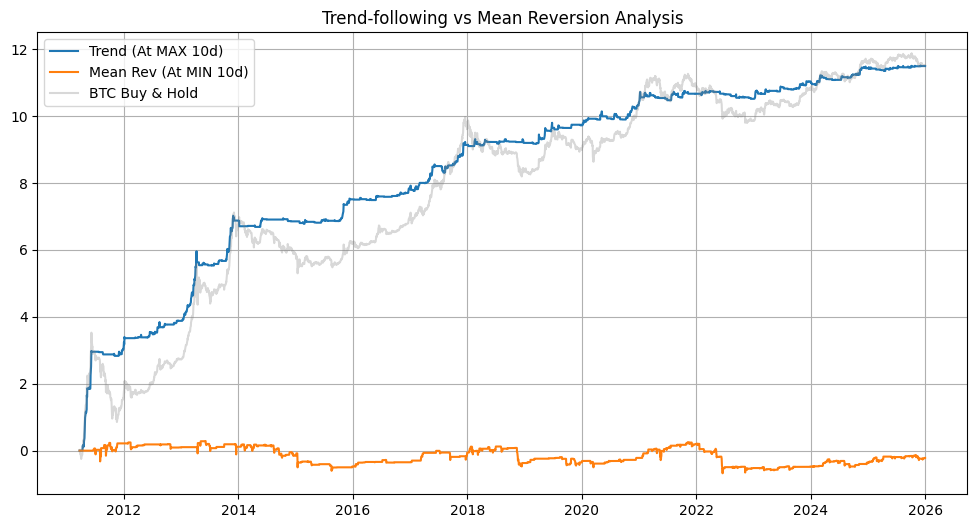

In [ ]:
# -*- coding: utf-8 -*-
"""
Replication of "Seasonality, Trend-following, and Mean reversion in Bitcoin"
Padysak & Vojtko (2022)
Focus: Trend-following and Mean Reversion Only
"""

# ------------------------------------------------------------------------------
# 1. Install and import required libraries
# ------------------------------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import io
import os
from google.colab import files

# ------------------------------------------------------------------------------
# 2. Load and prepare data
# ------------------------------------------------------------------------------
if 'filename' not in locals() or not os.path.exists(filename):
    print("Please upload your CSV file.")
    uploaded = files.upload()
    filename = list(uploaded.keys())[0]
    content = uploaded[filename]
else:
    with open(filename, 'rb') as f:
        content = f.read()

df = pd.read_csv(io.BytesIO(content), sep='\t')
df.columns = [c.replace('<', '').replace('>', '').lower() for c in df.columns]
if 'time' not in df.columns:
    df['time'] = '00:00:00'

df['datetime'] = pd.to_datetime(df['date'] + ' ' + df['time'])
df = df.sort_values('datetime').reset_index(drop=True)
df.set_index('datetime', inplace=True)

cols_to_keep = [c for c in ['open', 'high', 'low', 'close'] if c in df.columns]
df = df[cols_to_keep]

# ------------------------------------------------------------------------------
# 3. Performance Metrics Function
# ------------------------------------------------------------------------------
def performance(returns):
    if len(returns) == 0:
        return 0, 0, 0, 0
    # Use log returns mean multiplied by 252 for annualization
    ann_ret = np.nanmean(returns) * 252
    ann_vol = np.nanstd(returns) * np.sqrt(252)
    # Cumulative returns for MDD
    cum_ret = np.cumsum(np.nan_to_num(returns))
    running_max = np.maximum.accumulate(cum_ret)
    drawdown = cum_ret - running_max
    max_dd = np.min(drawdown)
    ret_vol = ann_ret / ann_vol if ann_vol != 0 else np.nan
    return ann_ret, ann_vol, max_dd, ret_vol

# ------------------------------------------------------------------------------
# 4. Trend-following and Mean Reversion Analysis
# ------------------------------------------------------------------------------
df['return'] = np.log(df['close'] / df['close'].shift(1))

lookbacks = [10, 20, 30, 40, 50]
results_table = []

for x in lookbacks:
    df[f'max_{x}'] = df['close'].rolling(window=x).max()
    df[f'min_{x}'] = df['close'].rolling(window=x).min()

    # Signals based on previous day close to avoid look-ahead bias
    at_max = (df['close'].shift(1) == df[f'max_{x}'].shift(1))
    below_max = (df['close'].shift(1) < df[f'max_{x}'].shift(1))
    at_min = (df['close'].shift(1) == df[f'min_{x}'].shift(1))
    over_min = (df['close'].shift(1) > df[f'min_{x}'].shift(1))

    for label, cond in [('Trend: At MAX', at_max), ('Mean Rev: Below MAX', below_max),
                        ('Mean Rev: At MIN', at_min), ('Trend: Over MIN', over_min)]:
        # Ensure we only calculate returns when conditions are met and return exists
        strat_ret = df['return'] * cond.astype(int)
        ann_ret, ann_vol, mdd, rv = performance(strat_ret.dropna())
        results_table.append({'Lookback': x, 'Strategy': label, 'Ann_Return': ann_ret, 'Volatility': ann_vol, 'MDD': mdd, 'Ret/Vol': rv})

table_df = pd.DataFrame(results_table)
print("\nTable: Trend-following and Mean Reversion Performance")
print(table_df.round(4))

# Plotting Best Trend-following vs Mean Reversion
plt.figure(figsize=(12, 6))
x_val = 10
plt.plot(df.index, (df['return'] * (df['close'].shift(1) == df[f'max_{x_val}'].shift(1)).astype(int)).cumsum(), label=f'Trend (At MAX {x_val}d)')
plt.plot(df.index, (df['return'] * (df['close'].shift(1) == df[f'min_{x_val}'].shift(1)).astype(int)).cumsum(), label=f'Mean Rev (At MIN {x_val}d)')
plt.plot(df.index, df['return'].cumsum(), label='BTC Buy & Hold', alpha=0.3, color='grey')
plt.legend()
plt.title('Trend-following vs Mean Reversion Analysis')
plt.grid(True)
plt.show()

```markdown
## Optimized Strategy: ATR Filter & Trailing Stops
This optimization introduces:
1. **ATR Filter**: Entries only occur if the breakout is accompanied by a certain level of volatility (avoiding 'fakeouts').
2. **Dynamic Exit**: Instead of waiting for the price to drop below a lookback low, we use a trailing stop based on a multiple of ATR.
```

Optimized Strategy (ATR Trailing Stop - Fixed Return Logic):
Annualized Return: 69.40%
Return/Volatility Ratio: 1.46


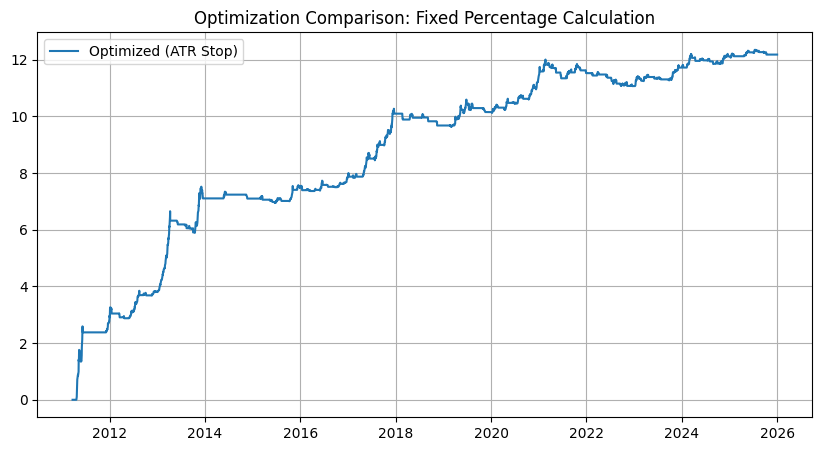

In [ ]:
# 1. Calculate ATR for volatility filtering
def calculate_atr(df, window=14):
    high_low = df['high'] - df['low']
    high_close = np.abs(df['high'] - df['close'].shift())
    low_close = np.abs(df['low'] - df['close'].shift())
    ranges = pd.concat([high_low, high_close, low_close], axis=1)
    true_range = np.max(ranges, axis=1)
    return true_range.rolling(window=window).mean()

df['atr'] = calculate_atr(df)

# 2. Optimized Logic with ATR validation
lookback = 20
atr_multiplier = 2.0
df['max_lookback'] = df['close'].rolling(window=lookback).max()

# Initialization
position = 0
stop_loss = 0
optimized_returns = np.zeros(len(df))

for i in range(1, len(df)):
    current_price = df['close'].iloc[i]
    current_atr = df['atr'].iloc[i]

    # Skip if ATR is not yet available (NaN)
    if pd.isna(current_atr):
        continue

    if position == 0:
        # Entry condition based on previous day's state
        if df['close'].iloc[i-1] == df['max_lookback'].iloc[i-1]:
            position = 1
            stop_loss = current_price - (atr_multiplier * current_atr)
    else:
        # Calculate log return for the day in position
        daily_ret = np.log(df['close'].iloc[i] / df['close'].iloc[i-1])
        optimized_returns[i] = daily_ret

        # Check Exit: Price hits trailing stop
        if current_price < stop_loss:
            position = 0
        else:
            # Update Trailing Stop
            new_stop = current_price - (atr_multiplier * current_atr)
            stop_loss = max(stop_loss, new_stop)

df['opt_strat_ret'] = optimized_returns

# Performance Comparison using updated performance metrics
ann_ret_opt, ann_vol_opt, mdd_opt, rv_opt = performance(df['opt_strat_ret'])

print(f"Optimized Strategy (ATR Trailing Stop - Fixed Return Logic):")
print(f"Annualized Return: {ann_ret_opt*100:.2f}%")
print(f"Return/Volatility Ratio: {rv_opt:.2f}")

plt.figure(figsize=(10, 5))
plt.plot(df.index, df['opt_strat_ret'].cumsum(), label='Optimized (ATR Stop)')
plt.title('Optimization Comparison: Fixed Percentage Calculation')
plt.legend()
plt.grid(True)
plt.show()